# Stochastic Local Volatility Calibration & Forward-Starting Call Spread Pricing

**Particle Method for Smile Calibration -- McKean-Vlasov SDE Approach**

*Walid Canesse -- M2MO Modélisation Aléatoire, Université Paris Cité (2025-2026)*

---

## **Motivation**

In quantitative finance, the Black-Scholes model assumes **constant volatility**, which produces flat implied volatility smiles -- a poor match for the patterns observed in equity markets (skew, smile, term structure). In practice, the implied volatility surface exhibits:

- A pronounced **skew** on equity indices (OTM puts are more expensive than OTM calls),
- **Smile dynamics** that depend on the current level of spot and recent realized vol,
- **Path-dependent** behaviour: after a crash, realized vol spikes -- something Black-Scholes can never capture because every trajectory lives in the same constant-$\sigma$ world.

**Stochastic Local Volatility (SLV) models** address this by combining:
1. A **stochastic volatility** component $a_t$ (e.g. driven by an Ornstein-Uhlenbeck process), which generates realistic vol dynamics,
2. A **leverage function** $l(t, S)$, which acts as a correction factor ensuring the model is **perfectly calibrated** to the market's vanilla option prices.

The key idea: the stochastic vol $a_t$ gives the model its "soul" (realistic trajectory shapes, vol clustering, skew dynamics), while the leverage function $l(t,S)$ ensures the model prices vanillas correctly -- just like Dupire's local vol, but without the unrealistic trajectory dynamics of pure local vol.

This notebook implements the **particle method** for calibrating $l(t,S)$ and demonstrates that the calibrated SLV model:
- Reproduces market vanilla prices exactly (by construction),
- Produces **different prices** from Black-Scholes for path-dependent exotics -- here, a forward-starting call spread.


## **1. Theoretical Background**

### 1.1 The General SLV Model

Under the risk-neutral measure, with deterministic (or stochastic) rate $r_t$ and dividend yield $q_t$, the spot price follows:

$$
\frac{dS_t}{S_t} = (r_t - q_t)\,dt + \sigma(t, S_t)\,a_t\,dW_t
$$

where:
- $a_t$ is the **stochastic volatility** process, driven by its own diffusion (one can choose any model: Ornstein-Uhlenbeck, Heston, SABR, etc.). It captures the randomness of volatility.
- $\sigma(t, S)$ is the **leverage function** — a deterministic correction that depends on time and on the current spot level. It forces the model to match the market's vanilla prices.
- $W_t$ is a standard Brownian motion (possibly correlated with the Brownian motion driving $a_t$).

One can assume rates and dividend yield stochastic, but we won't do that here.

The total instantaneous volatility of $S_t$ is therefore $\sigma(t, S_t) \cdot a_t$.
In Black-Scholes, one would have $\sigma \equiv 1$ and $a_t \equiv \sigma_{\text{BS}}$ constant — all trajectories share the same flat vol. The SLV model breaks this: the stochastic component $a_t$ creates realistic vol dynamics (clustering, mean-reversion, skew), while $\sigma(t,S)$ ensures exact calibration to market vanillas.

**Why is this useful in practice?** In Black-Scholes, every simulated trajectory lives in the same constant-$\sigma$ world: after a crash, the vol doesn't change. In the SLV model, if a trajectory has experienced a crash (low $S_t$), the leverage function $\sigma(t, S_t)$ combined with $a_t$ will produce a higher instantaneous vol — exactly as observed on equity markets. Conversely, after a calm rally, vol compresses. The SLV model captures this path-dependent behaviour, which is critical for pricing exotics.

### 1.2 Calibration Condition

The model is **exactly calibrated** to the market smile if and only if, for all $t$ and $K$:

$$
\sigma(t, K)^2 \, \mathbb{E}\!\left[a_t^2 \mid S_t = K\right] = \sigma_{\text{loc}}(t, K)^2
$$

where $\sigma_{\text{loc}}(t, K)$ is **Dupire's local volatility**, which can be extracted from market option prices via the Dupire formula.

Solving for $\sigma(t, x)$:

$$
\boxed{\sigma(t, x) = \frac{\sigma_{\text{loc}}(t, x)}{\sqrt{\mathbb{E}\!\left[a_t^2 \mid S_t = x\right]}}}
$$


### 1.3 The McKean-Vlasov (Nonlinear) SDE

Substituting the calibration condition back into the dynamics, the SDE becomes:

$$
\frac{dS_t}{S_t} = (r_t - q_t)\,dt + \frac{\sigma_{\text{loc}}(t, S_t)}{\sqrt{\mathbb{E}\!\left[a_t^2 \mid S_t\right]}} \, a_t \, dW_t
$$

This SDE is **nonlinear in the sense of McKean**: the diffusion coefficient depends not only on $(t, S_t, a_t)$ but also on the **law** of the pair $(S_t, a_t)$ through the conditional expectation $\mathbb{E}[a_t^2 \mid S_t]$. More precisely, the leverage function depends on the joint density $p(t, S, a)$ of $(S_t, a_t)$:

$$
\sigma(t, S, p) = \sigma_{\text{loc}}(t, S) \sqrt{\frac{\int p(t, S, a')\,da'}{\int a'^2 \, p(t, S, a')\,da'}}
$$

So there is a **triple dependence**: on time $t$, on space $(S_t, a_t)$, and on the probability measure $\mathcal{L}(S_t, a_t)$. This creates a fixed-point problem: the law of $S_t$ depends on $\sigma$, which depends on the law of $(S_t, a_t)$, which depends on $\sigma$, etc.

### 1.4 The Particle Method — Propagation of Chaos

To break this circularity, we use the **particle method**:
1. Replace the true law $P_t = \mathcal{L}(S_t, a_t)$ by an **empirical measure** $P_t^N$ based on $N$ simulated particles $(S_t^{(1)}, a_t^{(1)}), \ldots, (S_t^{(N)}, a_t^{(N)})$.
2. **Propagation of chaos** (Méléard, 1996) guarantees that as $N \to \infty$, the empirical measure $P_t^N$ converges weakly to $P_t$, and the particles become **i.i.d.**, each following the correct McKean-Vlasov law. This is a very powerful result: with enough particles, they "decouple" and each one independently follows the right distribution — no need to solve the fixed-point explicitly.

### 1.5 Kernel Regression for the Conditional Expectation

The key computational challenge is estimating $\mathbb{E}[a_t^2 \mid S_t = x]$ from the $N$ particles. We use **Nadaraya-Watson kernel regression**:

$$
\widehat{\mathbb{E}}[a_t^2 \mid S_t = x] = \frac{\sum_{i=1}^{N} (a_t^{(i)})^2 \, \delta_h\!\left(x - S_t^{(i)}\right)}{\sum_{i=1}^{N} \delta_h\!\left(x - S_t^{(i)}\right)}
$$

The idea: for each grid point $x$, we compute a weighted average of $a^2$ across all particles, where particles close to $x$ get high weight and particles far away get zero weight.

#### The kernel function

The kernel $\delta(u)$ assigns weights based on distance. We use the **quartic kernel**: $\delta(u) = (u+1)^2(1-u)^2$ for $|u| \le 1$, zero elsewhere. Any reasonable kernel works (Gaussian, Epanechnikov, triangular...) — the exact shape doesn't matter much.

**Quick numerical check that this kernel makes sense.** Suppose we want to estimate $\mathbb{E}[a^2 \mid S = 100]$ and we have three particles:

| Particle | $S_t^{(i)}$ | distance to 100 | $\delta(\text{dist})$ | $(a_t^{(i)})^2$ |
|----------|-------------|-----------------|----------------------|-----------------|
| 1 | 99.8 | $-0.2$ | $(0.8)^2(1.2)^2 = 0.922$ | $0.020$ |
| 2 | 100.0 | $0.0$ | $(1)^2(1)^2 = 1.000$ | $0.025$ |
| 3 | 100.5 | $0.5$ | $(1.5)^2(0.5)^2 = 0.563$ | $0.018$ |

Particle 2 (exactly at $x = 100$) gets the highest weight. Particle 1 (close) gets a high weight. Particle 3 (further) gets a lower weight. A particle at distance $> 1$ would get **exactly zero** — it doesn't contribute at all. This is exactly what we want: a localized average around $x$.

**What would a bad kernel look like?** $\delta(u) = 1$ for all $u$ (flat kernel). Every particle gets the same weight regardless of distance — we'd just compute the global average $\frac{1}{N}\sum (a_t^{(i)})^2$, which is $\mathbb{E}[a_t^2]$, not the **conditional** expectation $\mathbb{E}[a_t^2 \mid S_t = x]$. The whole point of the kernel is to localize.

#### Why rescaling is necessary

The raw quartic kernel gives zero weight to anything at distance $> 1$. But in our problem, $S_t$ lives around 100, so the distance between a particle at $S = 99$ and the grid point $x = 100$ is 1 — already at the boundary. A particle at $S = 98$ would get zero weight, even though it's perfectly "close" on the scale of the problem.

The **rescaled kernel** $\delta_h(x) = \frac{1}{h}\delta\!\left(\frac{x}{h}\right)$ fixes this by stretching the window to size $h$. With $h = 2.4$ (a typical value in our setup), a particle at distance 2 from $x$ has rescaled distance $2/2.4 = 0.83$, so $\delta(0.83) = (1.83)^2(0.17)^2 = 0.097$ — it still contributes. Without rescaling, it would get exactly zero.

#### How is $h$ chosen?

$$
h = \kappa \cdot \sigma_{\text{Market}} \cdot S_0 \cdot \sqrt{\max(t_k, t_{\min})} \cdot N^{-1/5}
$$

The bandwidth scales with the **spread of the particles** ($\sigma \cdot S_0 \cdot \sqrt{t}$ is roughly the std of $S_t$) and shrinks as $N^{-1/5}$ (more particles → finer resolution, classical nonparametric rate from bias-variance tradeoff). The parameter $\kappa \in [1, 3]$ is a fine-tuning constant; we take $\kappa = 1$.


### 1.6 The Grid

Computing $\sigma(t_k, x)$ for every possible $x$ would be too expensive. Instead, at each time step $t_k$:
1. Define a **grid** of $n_{\text{grid}}$ points between the $0.1\%$ and $99.9\%$ quantiles of $S_{t_k}$ (assuming lognormal marginals: $S_{t_k} \approx S_0 e^{-\frac{1}{2}\sigma^2 t_k + \sigma \sqrt{t_k} Z}$),
2. Compute $\sigma(t_k, \cdot)$ on this grid by kernel regression,
3. For particles between grid points: **linear interpolation**. For particles outside the grid: **constant extrapolation** (flat extension of boundary values).



## **2. Model Specification**


### 2.1 From the General Framework to Our Project

In the general SLV model above, we wrote $\sigma(t, S_t) \cdot a_t$ for the total instantaneous vol. In this project, we use the equivalent notation $l(t, S_t) \cdot a_t$ where $l \equiv \sigma$ is the leverage function, and we specialize to:

- **No drift:** $r_t = q_t = 0$ (zero rates and dividends),
- **Stochastic vol:** $a_t = \sigma_0 \, e^{Y_t}$ where $Y_t$ follows an **Ornstein-Uhlenbeck** process,
- **Flat market vol:** $\sigma_{\text{loc}}(t,x) = \sigma_{\text{Market}} = 15\%$ for all $(t,x)$ — the simplest possible case, where the market smile is flat.

The full system reads:

$$
\begin{cases}
dS_t = a_t \, l(t, S_t) \, S_t \, dW_t^{(1)} \\[6pt]
a_t = \sigma_0 \, e^{Y_t}, \quad dY_t = -\kappa \, Y_t \, dt + \gamma \, dW_t^{(2)} \\[6pt]
d\langle W^{(1)}, W^{(2)} \rangle_t = \rho \, dt
\end{cases}
$$

and the calibration condition becomes:

$$
l(t, x) = \frac{\sigma_{\text{Market}}}{\sqrt{\mathbb{E}\!\left[a_t^2 \mid S_t = x\right]}} = \frac{0.15}{\sqrt{\mathbb{E}\!\left[\sigma_0^2 e^{2Y_t} \mid S_t = x\right]}}
$$

**Parameters:**

| Parameter | Value | Description |
|-----------|-------|-------------|
| $T$ | 1 | Maturity |
| $S_0$ | 100 | Initial spot |
| $\sigma_0$ | 15% | Base volatility |
| $Y_0$ | 0 | Initial OU state |
| $\rho$ | $-50\%$ | Spot-vol correlation |
| $\gamma$ | 50% | Vol-of-vol |
| $\kappa$ | 1 | Mean-reversion speed |


**The goal is to find a leverage function $l(t, S)$ so that this model matches the market prices of vanilla options.**

### 2.2 Monte Carlo Simulation Scheme

Now that we have the model and the calibration condition for $l(t,x)$, we need to **simulate** the system $(S_t, Y_t)$ numerically. We discretize $(0, T)$ into $n$ subintervals $(t_{i-1}, t_i)$, $1 \le i \le n$, with $\Delta t_i = t_i - t_{i-1}$.

The question is: how do we advance the pair $(\log S, Y)$ from $t_{i-1}$ to $t_i$?

---

#### Step 1 — Simulating $Y$: exact transition (no Euler needed)

The OU process $Y$ has a **closed-form solution** (this is a standard result for linear SDEs: multiply both sides of $dY_t = -\kappa Y_t\,dt + \gamma\,dW_t^{(2)}$ by the integrating factor $e^{\kappa t}$ and integrate):

$$
Y_{t_i} = e^{-\kappa \Delta t_i} Y_{t_{i-1}} + \int_{t_{i-1}}^{t_i} \gamma\, e^{-\kappa(t_i - s)}\,dW_s^{(2)}
$$

The integral $\int_{t_{i-1}}^{t_i} \gamma\, e^{-\kappa(t_i-s)}\,dW_s^{(2)}$ is a stochastic integral of a deterministic function against a Brownian motion, so it is **Gaussian** with mean zero and variance $\int_{t_{i-1}}^{t_i} \gamma^2 e^{-2\kappa(t_i-s)}\,ds = \frac{\gamma^2}{2\kappa}(1 - e^{-2\kappa\Delta t_i})$ (by Itô isometry). Therefore, conditional on $Y_{t_{i-1}}$:

$$
\mathbb{E}\!\left[Y_{t_i} \mid Y_{t_{i-1}}\right] = e^{-\kappa \Delta t_i} Y_{t_{i-1}}, \qquad \text{Var}\!\left[Y_{t_i} \mid Y_{t_{i-1}}\right] = \frac{\gamma^2}{2\kappa}\left(1 - e^{-2\kappa \Delta t_i}\right) \tag{1}
$$

This means we can simulate $Y$ **exactly** — no Euler approximation, zero discretization error on the vol process.

---

#### Step 2 — Simulating $\log S$: why log-prices, and the Euler scheme

**Why work with $\log S$ instead of $S$?** Two reasons:
1. **No negative spots:** $S_{t_i} = e^{\log S_{t_i}}$ is always positive by construction, whereas a naive Euler on $S$ can produce negative values for large time steps.
2. **Better accuracy:** Itô's formula gives a clean expression for $d\log S_t$ with a drift correction of $-\frac{1}{2}(\text{vol})^2\,dt$.

Applying Itô's formula to $\log S_t$ and discretizing (Euler scheme on $\log S$):

$$
\log S_{t_i} - \log S_{t_{i-1}} = -\frac{1}{2}\sigma_0^2 e^{2Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}})^2 \Delta t_i + \sigma_0\, e^{Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}}) \int_{t_{i-1}}^{t_i} dW_s^{(1)}
$$

---
#### Step 3 — The joint law of $(\log S_{t_i}, Y_{t_i})$: computing the correlation we need for simulation

Conditional on $(S_{t_{i-1}}, Y_{t_{i-1}})$, both $\log S_{t_i}$ and $Y_{t_i}$ are **affine functions of Gaussian integrals** against $W^{(1)}$ and $W^{(2)}$ (which are correlated with $d\langle W^{(1)}, W^{(2)}\rangle = \rho\,dt$). So the pair is **jointly Gaussian**.

**Why do we care?** To simulate a jointly Gaussian pair, we need exactly three things: the two marginal distributions (mean and variance of each — done in Steps 1 and 2) and the **correlation** between them. Once we have this correlation, we can use the standard Cholesky trick to generate the pair from two independent standard normals. So the whole point of this step is to compute that correlation.

**Marginals** (from Steps 1 and 2):

$$
\mathbb{E}\!\left[\log S_{t_i} \mid S_{t_{i-1}}, Y_{t_{i-1}}\right] = \log S_{t_{i-1}} - \frac{1}{2}\sigma_0^2 e^{2Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}})^2 \Delta t_i \tag{2a}
$$

$$
\text{Var}\!\left[\log S_{t_i} \mid S_{t_{i-1}}, Y_{t_{i-1}}\right] = \sigma_0^2 e^{2Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}})^2 \Delta t_i \tag{2b}
$$

**Computing the covariance.** We want $\text{Cov}\!\left[Y_{t_i},\, \log S_{t_i} \;\middle|\; \mathcal{F}_{t_{i-1}}\right]$. By definition of the conditional covariance:

$$
\text{Cov}[X, Y \mid \mathcal{F}] = \mathbb{E}\!\left[\left(X - \mathbb{E}[X \mid \mathcal{F}]\right)\left(Y - \mathbb{E}[Y \mid \mathcal{F}]\right) \;\middle|\; \mathcal{F}\right]
$$

So we need to identify the **random part** of each variable (what remains after subtracting the conditional mean).

From Step 1, the random part of $Y_{t_i}$ is:

$$
Y_{t_i} - \mathbb{E}[Y_{t_i} \mid \mathcal{F}_{t_{i-1}}] = \int_{t_{i-1}}^{t_i} \gamma\, e^{-\kappa(t_i - s)}\,dW_s^{(2)}
$$

From Step 2, the random part of $\log S_{t_i}$ is (writing $v_{i-1} = \sigma_0\, e^{Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}})$ for the total vol frozen at $t_{i-1}$):

$$
\log S_{t_i} - \mathbb{E}[\log S_{t_i} \mid \mathcal{F}_{t_{i-1}}] = v_{i-1}\int_{t_{i-1}}^{t_i} dW_s^{(1)}
$$

Plugging into the covariance formula, and pulling out $v_{i-1}$ (which is $\mathcal{F}_{t_{i-1}}$-measurable, so it behaves as a constant conditionally):

$$
\text{Cov}\!\left[Y_{t_i}, \log S_{t_i} \mid \mathcal{F}_{t_{i-1}}\right] = v_{i-1} \cdot \mathbb{E}\!\left[\left(\int_{t_{i-1}}^{t_i} \gamma\, e^{-\kappa(t_i - s)}\,dW_s^{(2)}\right) \cdot \left(\int_{t_{i-1}}^{t_i} dW_s^{(1)}\right)\right]
$$

We now apply the **Itô isometry for two correlated Brownian motions**: if $d\langle W^{(1)}, W^{(2)}\rangle_s = \rho\,ds$, then

$$
\mathbb{E}\!\left[\int_a^b f(s)\,dW_s^{(1)} \cdot \int_a^b g(s)\,dW_s^{(2)}\right] = \rho \int_a^b f(s)\,g(s)\,ds
$$

Here $f(s) = 1$ (the integrand of $W^{(1)}$) and $g(s) = \gamma\, e^{-\kappa(t_i - s)}$ (the integrand of $W^{(2)}$), so:

$$
= v_{i-1} \cdot \rho \int_{t_{i-1}}^{t_i} 1 \cdot \gamma\, e^{-\kappa(t_i - s)}\,ds = v_{i-1} \cdot \gamma\rho \int_{t_{i-1}}^{t_i} e^{-\kappa(t_i - s)}\,ds
$$

Computing the deterministic integral with the substitution $u = t_i - s$:

$$
\int_{t_{i-1}}^{t_i} e^{-\kappa(t_i - s)}\,ds = \int_0^{\Delta t_i} e^{-\kappa u}\,du = \left[-\frac{1}{\kappa}e^{-\kappa u}\right]_0^{\Delta t_i} = \frac{1}{\kappa}\left(1 - e^{-\kappa \Delta t_i}\right)
$$

Substituting back $v_{i-1} = \sigma_0\, e^{Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}})$:

$$
\text{Cov}\!\left[Y_{t_i}, \log S_{t_i} \mid \mathcal{F}_{t_{i-1}}\right] = \sigma_0\, e^{Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}}) \cdot \frac{\gamma\rho}{\kappa}\left(1 - e^{-\kappa \Delta t_i}\right) \tag{3a}
$$

**From covariance to correlation.** Dividing by $\text{Std}(Y_{t_i}) \cdot \text{Std}(\log S_{t_i})$ — using the variances from (1) and (2b):

$$
\text{Std}(Y_{t_i}) = \gamma\sqrt{\frac{1 - e^{-2\kappa\Delta t_i}}{2\kappa}}, \qquad \text{Std}(\log S_{t_i}) = v_{i-1}\sqrt{\Delta t_i}
$$

$$
\bar{\rho} = \frac{\text{Cov}}{\text{Std}(Y_{t_i}) \cdot \text{Std}(\log S_{t_i})} = \frac{v_{i-1} \cdot \frac{\gamma\rho}{\kappa}(1 - e^{-\kappa\Delta t_i})}{v_{i-1}\sqrt{\Delta t_i} \cdot \gamma\sqrt{\frac{1 - e^{-2\kappa\Delta t_i}}{2\kappa}}}
$$

The $v_{i-1}$ and $\gamma$ cancel. Using $1 - e^{-2\kappa\Delta t_i} = (1 - e^{-\kappa\Delta t_i})(1 + e^{-\kappa\Delta t_i})$:

$$
\boxed{\bar{\rho} \;=\; \rho\,\sqrt{\frac{2(1 - e^{-\kappa \Delta t_i})}{\kappa \Delta t_i\,(1 + e^{-\kappa \Delta t_i})}}} \tag{3b}
$$

---

#### Step 4 — The complete update: generating correlated Gaussians

Now we have everything: the marginal mean and variance of each variable (Steps 1–2), and their correlation $\bar{\rho}$ (Step 3). To simulate a bivariate Gaussian with correlation $\bar{\rho}$ from two **independent** standard normals $Z_1, Z_2 \sim \mathcal{N}(0,1)$, we use the Cholesky decomposition of the correlation matrix $\begin{pmatrix} 1 & \bar{\rho} \\ \bar{\rho} & 1\end{pmatrix} = L L^\top$ where $L = \begin{pmatrix} 1 & 0 \\ \bar{\rho} & \sqrt{1-\bar{\rho}^2}\end{pmatrix}$. This gives the recipe: one variable uses $Z_2$ alone, the other uses $\bar{\rho}\,Z_2 + \sqrt{1-\bar{\rho}^2}\,Z_1$.

Plugging the marginals from Steps 1–2 and the correlation from Step 3:

$$
\boxed{
\begin{aligned}
Y_{t_i} &= e^{-\kappa \Delta t_i} Y_{t_{i-1}} + \gamma\sqrt{\frac{1 - e^{-2\kappa \Delta t_i}}{2\kappa}}\;Z_2 \\[10pt]
\log S_{t_i} &= \log S_{t_{i-1}} - \frac{1}{2}v_{i-1}^2\,\Delta t_i + v_{i-1}\sqrt{\Delta t_i}\left(\sqrt{1 - \bar{\rho}^2}\;Z_1 + \bar{\rho}\;Z_2\right)
\end{aligned}
}
$$

where $v_{i-1} = \sigma_0\,e^{Y_{t_{i-1}}}\,l(t_{i-1}, S_{t_{i-1}})$ is the total instantaneous vol frozen at $t_{i-1}$.

### 2.3 Kernel 

$$\delta(x)=(x+1)^2(1-x)^2\quad\text{for }-1\leq x\leq 1\quad\text{and}\quad0\quad\text{ elsewhere}$$

together with the bandwidth 

$$h = \kappa \sigma_{\mathrm{Market}} S_0 \sqrt{\max(t_k,0.15)}N^{-0.2}$$

at discretization date $t_k$. 

We recall that the rescaled kernel is 

$$ \delta_h(x) = \frac{1}{h}\delta\left(\frac{x}{h}\right). $$

### **2.4 The algorithm step by step**

**We summarize the complete algorithm derived in sections 2.1–2.3 above. This is the recipe that the code in Section 3 implements directly.**

### 1. Particle Simulation Scheme

From 2.2 : we draw $Z_1, Z_2$, two **independent** $\mathcal{N}(0,1)$ variables for each particle $i$, then:

$$
\boxed{\log S_{t_i} = \log S_{t_{i-1}} - \frac{1}{2}\sigma_0^2 e^{2Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}})^2 \Delta t_i + \sigma_0 e^{Y_{t_{i-1}}} l(t_{i-1}, S_{t_{i-1}}) \sqrt{\Delta t_i} \left(\sqrt{1 - \bar{\rho}^2}\, Z_1 + \bar{\rho}\, Z_2\right)}
$$

$$
\boxed{Y_{t_i} = e^{-\kappa \Delta t_i} Y_{t_{i-1}} + \gamma \sqrt{\frac{1 - e^{-2\kappa \Delta t_i}}{2\kappa}} \, Z_2}
$$

We recover the spot via $S_{t_i} = \exp(\log S_{t_i})$.

> **Caution:** We use $\bar{\rho}$ (corrected discrete correlation) and not $\rho$ directly.

---

### 2. Conditional Expectation Estimator

For a grid point $x$:

$$
\boxed{\mathbb{E}[a_{t_k}^2 \mid S_{t_k} = x] \approx \frac{\displaystyle\sum_{i=1}^{N} (a_{t_k}^{(i)})^2 \cdot \delta_h\!\left(x - S_{t_k}^{(i)}\right)}{\displaystyle\sum_{i=1}^{N} \delta_h\!\left(x - S_{t_k}^{(i)}\right)}}
$$

where $a_{t_k}^{(i)} = \sigma_0 \exp(Y_{t_k}^{(i)})$.

---

#### **Complete Algorithm**

##### Parameters

- $N = 10\,000$ particles
- $\Delta t = 1/100$ → **100 time steps**
- 30-point grid for the spot at each time step

##### Initialization ($t_0 = 0$)

All particles start at $(S_0^{(i)}, Y_0^{(i)}) = (100, 0)$ for $i = 1, \dots, N$.

We have $a_0^{(i)} = \sigma_0 e^{0} = 0.15$ for all $i$, so:

$$
\mathbb{E}[a_0^2 \mid S_0 = 100] = 0.15^2
$$

$$
l(0, 100) = \frac{0.15}{0.15} = 1
$$

##### Iteration $k$: moving from $t_{k-1}$ to $t_k$

**For each particle** $i = 1, \dots, N$:

1. Draw independent $Z_1^{(i)}, Z_2^{(i)} \sim \mathcal{N}(0,1)$.
2. Calculate $Y_{t_k}^{(i)}$ using the exact scheme (boxed eq. above).
3. Calculate $\log S_{t_k}^{(i)}$ using the Euler scheme (boxed eq. above), using $l(t_{k-1}, S_{t_{k-1}}^{(i)})$ evaluated by interpolation.
4. Recover $S_{t_k}^{(i)} = \exp(\log S_{t_k}^{(i)})$.

**Preparation of $l(t_k, \cdot)$**:

- **Sub-step 1** — Grid construction:
  - Calculate $S_{\min}$ and $S_{\max}$ as the 0.1% and 99.9% quantiles of the distribution $S_0 \exp\!\left(\sigma_{\text{Market}}\sqrt{t_k}\, G - \tfrac{1}{2}\sigma_{\text{Market}}^2 t_k\right)$ with $G \sim \mathcal{N}(0,1)$.
  - Construct a grid $G_{t_k}$ of 30 equidistant points between $S_{\min}$ and $S_{\max}$.

- **Sub-step 2** — Calculation of $a_{t_k}^{(i)}$:

$$
\left(a_{t_k}^{(i)}\right)^2 = \sigma_0^2 \exp\!\left(2\, Y_{t_k}^{(i)}\right) \quad \text{for } i = 1, \dots, N
$$

- **Sub-step 3** — Conditional expectation estimation:
  - For each point $x$ on the grid $G_{t_k}$, calculate $\mathbb{E}[a_{t_k}^2 \mid S_{t_k} = x]$ via the previously given estimator.

- **Sub-step 4** — Calculation of the leverage function on the grid:

$$
l(t_k, x) = \frac{\sigma_{\text{Market}}}{\sqrt{\mathbb{E}[a_{t_k}^2 \mid S_{t_k} = x]}} \quad \text{for each } x \in G_{t_k}
$$

- **Sub-step 5** — Interpolation and extrapolation:
  - Linear interpolation between the 30 grid points.
  - Constant extrapolation: $l(t_k, x) = l(t_k, S_{\min})$ for $x < S_{\min}$ and $l(t_k, x) = l(t_k, S_{\max})$ for $x > S_{\max}$.
  - (`numpy.interp` does both at once.)

- **Sub-step 6** — Storage:
  - Store the grid $(G_{t_k}, l(t_k, G_{t_k}))$ for reuse in Step 2.

##### Repeat for $k = 1, \dots, 100$

**At the end, we have 100 stored leverage functions $l(t_k, \cdot)$.**


## **3. Implementation**

In [4]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})


### 3.1 Black-Scholes Pricing & Implied Volatility Inversion

In [5]:
def blackscholes_price(K, T, S, vol, r=0, q=0, callput='call'):
    """Black-Scholes option price."""
    F = S * np.exp((r - q) * T)
    w = vol**2 * T
    d1 = (np.log(F / K) + 0.5 * w) / np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    opttype = 1 if callput.lower() == 'call' else -1
    return (opttype * F * norm.cdf(opttype * d1) - opttype * K * norm.cdf(opttype * d2)) * np.exp(-r * T)


def blackscholes_impv_scalar(K, T, S, value, r=0, q=0, callput='call', tol=1e-6, maxiter=500):
    """Compute implied vol via rational approximation (Jaeckel)."""
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S * np.exp((r - q) * T)
    K_norm = K / F
    value_norm = value * np.exp(r * T) / F
    opttype = 1 if callput.lower() == 'call' else -1
    value_norm -= max(opttype * (1 - K_norm), 0)
    if value_norm < 0:
        return np.nan
    if value_norm == 0:
        return 0.0
    j = 1
    p = np.log(K_norm)
    if K_norm >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K_norm * norm.cdf(-x0) - value_norm) * np.sqrt(2 * np.pi)
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (norm.cdf(d1) - K_norm * norm.cdf(d1 - x1) - value_norm) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
        return x1 / np.sqrt(T)
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5 * K_norm - norm.cdf(-x0) - value_norm) * np.sqrt(2 * np.pi) / K_norm
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (K_norm * norm.cdf(x1 - d1) - norm.cdf(-d1) - value_norm) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
        return x1 / np.sqrt(T)

blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={'callput', 'tol', 'maxiter'})


### 3.2 Model Parameters & Particle Method Core Functions

In [6]:
# ============================================================
# Model parameters
# ============================================================
T = 1.0
S0 = 100.0
sigma0 = 0.15
Y0 = 0.0
rho = -0.50
gamma = 0.50
kappa_model = 1.0
sigma_market = 0.15

# Simulation parameters
n_steps = 100
dt = T / n_steps
N_calib = 10_000       # particles for calibration
N_pricing = 100_000    # paths for pricing
n_grid = 30            # grid points for leverage function

# Strikes for validation
strikes = np.array([70, 80, 90, 100, 110, 120, 130, 140], dtype=float)


In [7]:
# ============================================================
# Kernel regression utilities
# ============================================================

def quartic_kernel(u):
    """Quartic kernel: delta(u) = (u+1)^2 * (1-u)^2 for |u| <= 1, 0 elsewhere."""
    result = np.zeros_like(u)
    mask = np.abs(u) <= 1.0
    result[mask] = (u[mask] + 1.0)**2 * (1.0 - u[mask])**2
    return result


def kernel_rescaled(x, h):
    """Rescaled kernel: delta_h(x) = (1/h) * delta(x/h)."""
    return quartic_kernel(x / h) / h


def compute_bandwidth(t_k, kappa_bw, N):
    """Bandwidth: h = kappa_bw * sigma_market * S0 * sqrt(max(t_k, 0.15)) * N^{-0.2}."""
    return kappa_bw * sigma_market * S0 * np.sqrt(max(t_k, 0.15)) * N**(-0.2)


def build_grid(t_k):
    """Grid of n_grid points between quantiles 0.1% and 99.9% of log-normal S_{t_k}."""
    z_low = norm.ppf(0.001)
    z_high = norm.ppf(0.999)
    S_min = S0 * np.exp(sigma_market * np.sqrt(t_k) * z_low - 0.5 * sigma_market**2 * t_k)
    S_max = S0 * np.exp(sigma_market * np.sqrt(t_k) * z_high - 0.5 * sigma_market**2 * t_k)
    return np.linspace(S_min, S_max, n_grid)


def nadaraya_watson(grid, S_particles, a_squared, h):
    """Kernel regression estimator of E[a^2 | S = x] on a grid."""
    cond_expect = np.zeros(len(grid))
    for j in range(len(grid)):
        weights = kernel_rescaled(grid[j] - S_particles, h)
        total_weight = np.sum(weights)
        if total_weight > 1e-12:
            cond_expect[j] = np.sum(a_squared * weights) / total_weight
        else:
            cond_expect[j] = sigma_market**2
    return cond_expect


def leverage_from_cond_expect(cond_expect):
    """l(t_k, x) = sigma_market / sqrt(E[a^2 | S = x])."""
    return sigma_market / np.sqrt(cond_expect)


def eval_leverage(S_val, grid, leverage_values):
    """Evaluate l(t_k, S) by linear interpolation + constant extrapolation."""
    return np.interp(S_val, grid, leverage_values)


def rho_bar_func(rho_val, kappa_val, dt_val):
    """Discrete corrected correlation rho_bar."""
    if abs(rho_val) < 1e-12:
        return 0.0
    e = np.exp(-kappa_val * dt_val)
    return rho_val * np.sqrt(2.0 * (1.0 - e) / (kappa_val * dt_val * (1.0 + e)))


### 3.3 Calibration of the Leverage Function


In [8]:
def calibrate_leverage(rho_val, gamma_val, kappa_val, kappa_bw=1.0, seed=1975):
    """
    Calibrate l(t,x) by the particle method.
    
    Parameters
    ----------
    rho_val : float - spot-vol correlation
    gamma_val : float - vol-of-vol
    kappa_val : float - OU mean-reversion speed
    kappa_bw : float - bandwidth tuning parameter
    seed : int - random seed for reproducibility
    
    Returns
    -------
    leverage_storage : list of (grid, leverage_values) tuples, one per time step
    """
    np.random.seed(seed)
    
    # Precompute constants
    e_kdt = np.exp(-kappa_val * dt)
    if gamma_val > 0:
        std_Y_val = gamma_val * np.sqrt((1.0 - np.exp(-2.0 * kappa_val * dt)) / (2.0 * kappa_val))
    else:
        std_Y_val = 0.0
    rho_bar_val = rho_bar_func(rho_val, kappa_val, dt)

    # Initialize particles
    S_log = np.full(N_calib, np.log(S0))
    Y = np.full(N_calib, Y0)

    leverage_storage = [(np.array([S0]), np.array([1.0]))]

    for k in range(1, n_steps + 1):
        t_k = k * dt
        Z1 = np.random.randn(N_calib)
        Z2 = np.random.randn(N_calib)

        # Evaluate leverage at previous step
        S_prev = np.exp(S_log)
        grid_prev, lev_prev = leverage_storage[k - 1]
        l_values = eval_leverage(S_prev, grid_prev, lev_prev)

        # a_{t_{k-1}} = sigma0 * exp(Y_{t_{k-1}})
        a_prev = sigma0 * np.exp(Y)

        # Exact OU update for Y
        Y = e_kdt * Y + std_Y_val * Z2

        # Euler update for log(S)
        vol_total = a_prev * l_values
        drift = -0.5 * vol_total**2 * dt
        diffusion = vol_total * np.sqrt(dt) * (np.sqrt(1.0 - rho_bar_val**2) * Z1 + rho_bar_val * Z2)
        S_log = S_log + drift + diffusion

        # Build leverage function at t_k
        grid_k = build_grid(t_k)
        a_squared = sigma0**2 * np.exp(2.0 * Y)
        h = compute_bandwidth(t_k, kappa_bw, N_calib)
        S_particles = np.exp(S_log)
        cond_expect = nadaraya_watson(grid_k, S_particles, a_squared, h)
        lev_k = leverage_from_cond_expect(cond_expect)
        leverage_storage.append((grid_k, lev_k))

    return leverage_storage


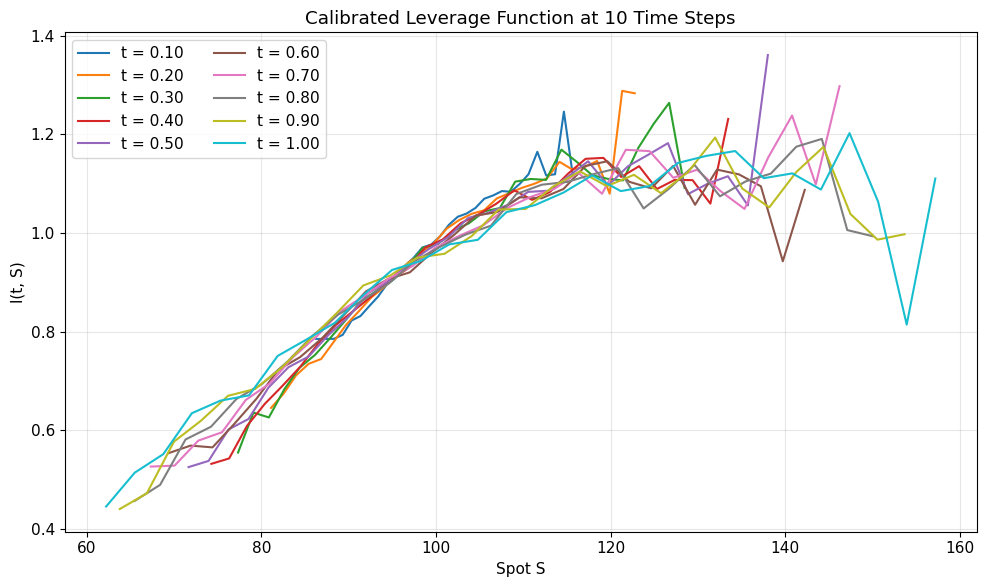

In [9]:
# Run calibration with default parameters
leverage_storage = calibrate_leverage(rho, gamma, kappa_model)

# Plot leverage functions at 10 dates
fig, ax = plt.subplots(figsize=(10, 6))
dates_to_plot = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for idx in dates_to_plot:
    grid_plot, lev_plot = leverage_storage[idx]
    ax.plot(grid_plot, lev_plot, label=f't = {idx * dt:.2f}')

ax.set_xlabel('Spot S')
ax.set_ylabel('l(t, S)')
ax.set_title('Calibrated Leverage Function at 10 Time Steps')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


### 3.4 Validation: Pricing Vanilla Calls

To verify calibration, we simulate $N_2 = 100\,000$ **independent** paths using the calibrated leverage functions (no recalibration -- we just use the stored $l(t_k, \cdot)$). For each strike $K$, we compute the call price:

$$
\hat{C}(T, K) = \frac{1}{N_2}\sum_{i=1}^{N_2} \max(S_T^{(i)} - K, 0)
$$

then invert Black-Scholes to get the implied vol.

If calibration is correct, all implied vols should be close to $\sigma_{\text{Market}} = 15\%$.


In [10]:
def price_calls_slv(leverage_storage, rho_val, gamma_val, kappa_val, seed=777):
    """Simulate N_pricing paths using calibrated leverage and price vanilla calls."""
    np.random.seed(seed)
    
    e_kdt = np.exp(-kappa_val * dt)
    std_Y_val = gamma_val * np.sqrt((1.0 - np.exp(-2.0 * kappa_val * dt)) / (2.0 * kappa_val)) if gamma_val > 0 else 0.0
    rho_bar_val = rho_bar_func(rho_val, kappa_val, dt)

    S_log_p = np.full(N_pricing, np.log(S0))
    Y_p = np.full(N_pricing, Y0)

    for k in range(1, n_steps + 1):
        Z1 = np.random.randn(N_pricing)
        Z2 = np.random.randn(N_pricing)

        S_prev = np.exp(S_log_p)
        grid_prev, lev_prev = leverage_storage[k - 1]
        l_values = eval_leverage(S_prev, grid_prev, lev_prev)
        a_prev = sigma0 * np.exp(Y_p)

        Y_p = e_kdt * Y_p + std_Y_val * Z2

        vol_total = a_prev * l_values
        drift = -0.5 * vol_total**2 * dt
        diffusion = vol_total * np.sqrt(dt) * (np.sqrt(1.0 - rho_bar_val**2) * Z1 + rho_bar_val * Z2)
        S_log_p = S_log_p + drift + diffusion

    S_T = np.exp(S_log_p)

    results = []
    for K in strikes:
        payoffs = np.maximum(S_T - K, 0.0)
        price = np.mean(payoffs)
        iv = blackscholes_impv(K=K, T=T, S=S0, value=price, callput='call')
        results.append((K, price, float(iv)))
    
    return results, S_T


results, _ = price_calls_slv(leverage_storage, rho, gamma, kappa_model)

# Display results
print(f"{'Strike':>10s} {'Call Price':>12s} {'Implied Vol':>14s}")
print("-" * 38)
for K, price, iv in results:
    print(f"{K:10.0f} {price:12.4f} {iv*100:12.2f}%")


    Strike   Call Price    Implied Vol
--------------------------------------
        70      30.0553        15.82%
        80      20.4286        15.21%
        90      12.0401        15.06%
       100       5.9647        14.97%
       110       2.4890        14.97%
       120       0.8816        14.95%
       130       0.2694        14.93%
       140       0.0716        14.87%


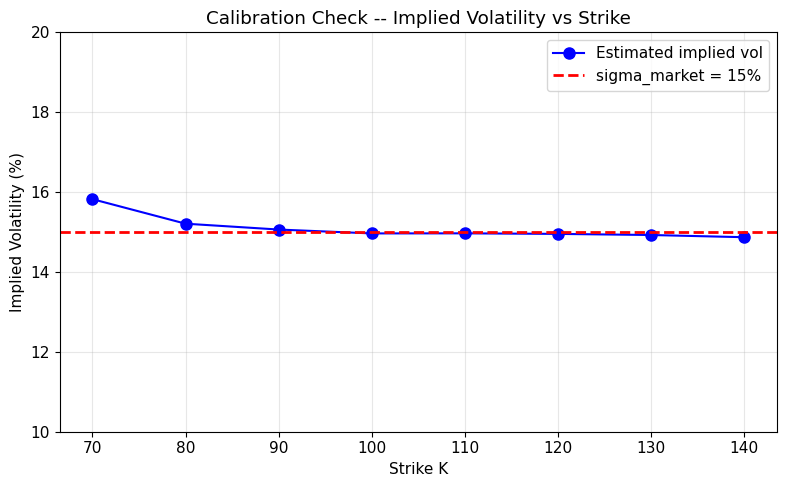

In [11]:
# Plot the implied volatility smile
fig, ax = plt.subplots(figsize=(8, 5))
ks = [r[0] for r in results]
ivs = [r[2] * 100 for r in results]
ax.plot(ks, ivs, 'bo-', markersize=8, label='Estimated implied vol')
ax.axhline(y=sigma_market * 100, color='r', linestyle='--', linewidth=2, label=f'sigma_market = {sigma_market*100:.0f}%')
ax.set_xlabel('Strike K')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('Calibration Check -- Implied Volatility vs Strike')
ax.legend()
ax.set_ylim([10, 20])
plt.tight_layout()
plt.show()


**Result:** The implied vols cluster tightly around 15% for all strikes, confirming successful calibration. Small deviations at extreme strikes (70, 140) are Monte Carlo noise -- deep OTM options have very few paths exercising, so the price estimate is noisier.

## **4. Parameter Sensitivity Analysis**

We study how the model parameters $(\gamma, \rho, \kappa)$ affect:
1. The **calibrated leverage function** $l(T, S)$,
2. The **implied vol smile** of the **pure stochastic vol model** ($l \equiv 1$, no calibration).


In [12]:
def simulate_sv_pure_smile(rho_val, gamma_val, kappa_val, seed=42):
    """Simulate the pure SV model (l = 1) and return implied vols."""
    np.random.seed(seed)
    
    e_kdt = np.exp(-kappa_val * dt)
    std_Y_val = gamma_val * np.sqrt((1.0 - np.exp(-2.0 * kappa_val * dt)) / (2.0 * kappa_val)) if gamma_val > 0 else 0.0
    rho_bar_val = rho_bar_func(rho_val, kappa_val, dt)

    S_log_sv = np.full(N_pricing, np.log(S0))
    Y_sv = np.full(N_pricing, Y0)

    for k in range(1, n_steps + 1):
        Z1 = np.random.randn(N_pricing)
        Z2 = np.random.randn(N_pricing)
        a_prev = sigma0 * np.exp(Y_sv)
        Y_sv = e_kdt * Y_sv + std_Y_val * Z2
        drift = -0.5 * a_prev**2 * dt
        diffusion = a_prev * np.sqrt(dt) * (np.sqrt(1.0 - rho_bar_val**2) * Z1 + rho_bar_val * Z2)
        S_log_sv = S_log_sv + drift + diffusion

    S_T_sv = np.exp(S_log_sv)
    ivs = []
    for K in strikes:
        price = np.mean(np.maximum(S_T_sv - K, 0.0))
        iv = blackscholes_impv(K=K, T=T, S=S0, value=price, callput='call')
        ivs.append(float(iv))
    return np.array(ivs)


### 4.1 Impact of $\gamma$ (Vol-of-Vol)

We fix $\rho = 0\%$, $\kappa = 1$ and vary $\gamma \in \{0\%, 25\%, 50\%, 75\%\}$.

#### What we are going to do

#### Task 1: Leverage function $l(T, S)$ for each $\gamma$

For each value of $\gamma$:
- Rerun the **calibration from question (a)** (particle method, $N = 10\,000$ particles, $\Delta t = 1/100$) with the parameters $(\rho = 0, \kappa = 1, \gamma)$.
- Retrieve the leverage function at maturity $l(T, \cdot)$, which is the last stored function ($k = 100$).
- Plot the 4 curves $l(T, S)$ as a function of $S$ **on the same graph**.

#### Task 2: Pure SV model smile for each $\gamma$

For each value of $\gamma$:
- Simulate the model **without leverage** ($l \equiv 1$) using $N_2 = 100\,000$ paths.
- Price calls for strikes $K \in \{70, 80, 90, 100, 110, 120, 130, 140\}$ using Monte Carlo.
- Invert Black-Scholes to obtain the implied volatilities $\hat{\sigma}(T, K)$.
- Plot the 4 smiles **on the same graph**.

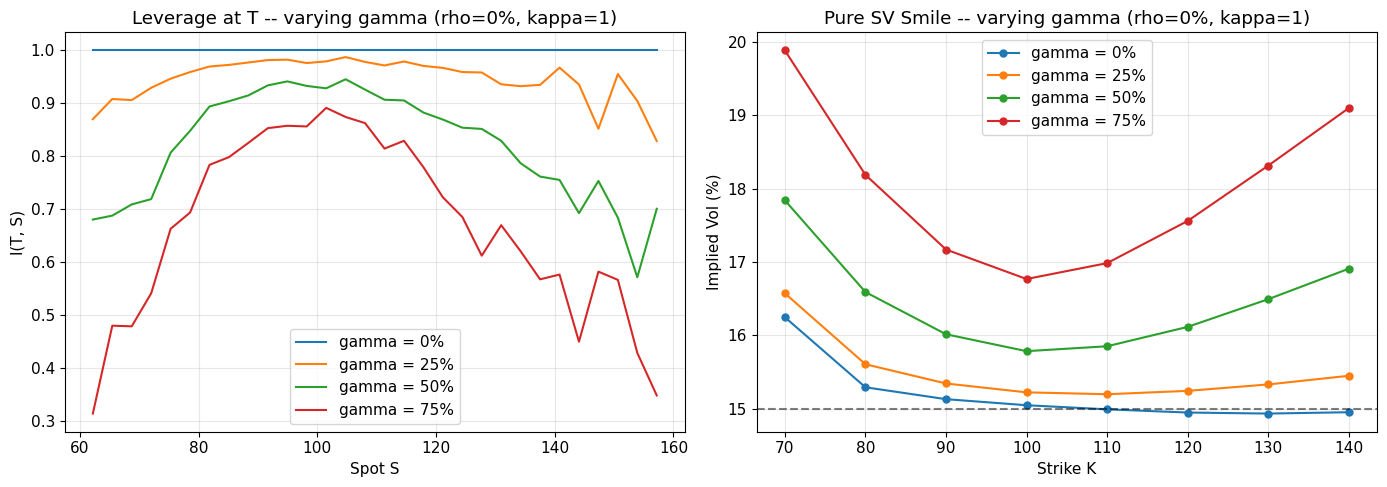

In [13]:
gamma_values = [0.0, 0.25, 0.50, 0.75]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Leverage functions
for gamma_val in gamma_values:
    lev_stor = calibrate_leverage(0.0, gamma_val, 1.0)
    grid_T, lev_T = lev_stor[-1]
    ax1.plot(grid_T, lev_T, label=f'gamma = {gamma_val*100:.0f}%')
ax1.set_xlabel('Spot S')
ax1.set_ylabel('l(T, S)')
ax1.set_title('Leverage at T -- varying gamma (rho=0%, kappa=1)')
ax1.legend()

# Pure SV smiles
for gamma_val in gamma_values:
    ivs = simulate_sv_pure_smile(0.0, gamma_val, 1.0)
    ax2.plot(strikes, ivs * 100, 'o-', ms=5, label=f'gamma = {gamma_val*100:.0f}%')
ax2.axhline(y=15, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Strike K')
ax2.set_ylabel('Implied Vol (%)')
ax2.set_title('Pure SV Smile -- varying gamma (rho=0%, kappa=1)')
ax2.legend()

plt.tight_layout()
plt.show()


#### Interpretation of results

##### Why $\gamma = 0$ yields=Black-Scholes

Let's start with the simplest case. When $\gamma = 0$, the SDE for process $Y$ becomes:

$$
dY_t = -\kappa Y_t \, dt + 0 \cdot dW_t^{(2)} = -\kappa Y_t \, dt
$$

There is no stochastic term left. It's a simple deterministic ODE. With the initial condition $Y_0 = 0$, the solution is obvious: $Y_t = 0$ for all $t$.

Consequently, the stochastic volatility $a_t = \sigma_0 e^{Y_t} = \sigma_0 e^0 = \sigma_0 = 15\%$ is **constant**. The model with $l = 1$ then becomes:

$$
dS_t = \sigma_0 \, S_t \, dW_t^{(1)}
$$

This is a classic geometric Brownian motion, meaning it's exactly the **Black-Scholes model** with $\sigma = 15\%$. There is no stochastic vol, no smile. The implied vol is flat at 15% for all strikes, and the leverage function is $l = 1$ everywhere because there is nothing to correct.

This is exactly what we observe on the two graphs: the blue curve ($\gamma = 0\%$) is a flat line at 15% on the smile, and a flat line at 1 on the leverage function.

**Note on boundary noise:** We notice that even for $\gamma = 0\%$, the smile curve is not perfectly flat — it dips slightly at extreme strikes ($K = 70$, $K = 140$). This is **Monte Carlo noise**, not a model effect. We estimate call prices with a finite number of paths ($N_2 = 100\,000$). For far-out-of-the-money strikes, very few trajectories end up in the money (few $S_T > 140$ or few $S_T < 70$), so the price estimator is noisier. When inverting Black-Scholes on a slightly biased price, it gives a slightly shifted implied vol. By increasing to $N_2 = 1\,000\,000$ paths, the curve would be almost perfectly flat.

---

##### Why a large $\gamma$ widens the smile

Now, when $\gamma > 0$, the vol $a_t = \sigma_0 e^{Y_t}$ is no longer constant: it **fluctuates randomly** around $\sigma_0$. The larger $\gamma$ is, the more $Y_t$ moves, and the more $a_t$ oscillates between high and low values.

Practically, what does this change for the distribution of the final price $S_T$?

Imagine drawing many paths. Sometimes $Y_t$ will be positive for a good part of the journey, so $a_t > \sigma_0$, the vol is high, and $S_T$ can end up very far from $S_0$ (very high or very low). Other times $Y_t$ will be negative, $a_t < \sigma_0$, and $S_T$ stays close to $S_0$. 

On average, this "volatility mixing" effect **fattens the tails** of the $S_T$ distribution compared to a classic lognormal (that of Black-Scholes). There is a higher probability that $S_T$ will be very far from $S_0$, in both directions.

Now, what does this do to option prices?

- A **deep OTM** call ($K = 140$): This is a bet that $S_T > 140$. It's a right-tail event. If the tail is fatter, this event is more likely, so the call is worth more.
- A **deep OTM** put ($K = 70$): This is a bet on $S_T < 70$. Same logic, fatter left tail, the put is worth more.
- An **ATM** call ($K = 100$): The ATM price depends mostly on the average volatility, not the tails. It is barely affected.

However, in Black-Scholes, an option that costs more than expected translates into a **higher implied volatility**. So the wings (strikes far from $S_0$) have an implied vol above 15%, while the center remains close to 15%.

Result: We get a **smile** — a U-shaped curve — and the larger $\gamma$ is, the fatter the tails, the more pronounced the smile. This is exactly what we observe on the pure SV smile graph.

---

##### Why the leverage function is less than 1

The calibrated SLV model must produce a **flat** smile at 15% (since we assumed a flat market surface). But we just saw that the pure SV ($l = 1$) naturally produces a smile **above** 15% in the wings when the vol of vol is greater than 0.

Therefore, the leverage function must **reduce** the local volatility so that option prices drop back to the 15% Black-Scholes level. Practically, $l(T, S) < 1$ means we **dampen** the spot diffusion: instead of $dS_t = a_t \cdot S_t \, dW_t^{(1)}$, we have $dS_t = a_t \cdot l(t, S_t) \cdot S_t \, dW_t^{(1)}$ with $l < 1$, so the spot moves less.

##### The shape of $l$ as a function of $S$

If we look at the shape of $l(T, S)$ on the graph:

- **In the center** ($S \approx 100$): $l$ is close to 1 (especially for small $\gamma$). This makes sense: the pure SV already gives an ATM implied vol close to 15%, there isn't much to correct.
- **In the wings** ($S$ far from 100): $l$ drops sharply below 1. This is where the pure SV produces too much vol (fat tails), so $l$ must compensate by reducing the local diffusion.

###### Summary

| $\gamma$ | Pure SV Smile | Leverage Function $l(T, S)$ |
|----------|-------------|------|
| $0\%$ | Flat at 15% (Black-Scholes) | $l = 1$ everywhere |
| $25\%$ | Slight symmetric smile | $l$ slightly below 1 |
| $50\%$ | More pronounced smile | $l$ drops lower, especially in the wings |
| $75\%$ | Very pronounced smile | $l$ far below 1, strong correction needed |

The link is clear: the more $\gamma$ produces a pronounced smile in pure SV, the further $l$ must deviate from 1 to compensate and bring the surface back to 15%.

### 4.2 Impact of $\rho$ (Spot-Vol Correlation)

We fix $\gamma = 50\%$, $\kappa = 1$ and vary $\rho \in \{-50\%, 0\%, 50\%\}$.

#### Context

We study the impact of $\rho$ (correlation between spot and volatility) on:
1. The calibrated leverage function $l(t, S)$ in the SLV model.
2. The volatility smile of the **pure SV** model (i.e., $l \equiv 1$).

Tested values: $\rho \in \{-50\%, 0\%, 50\%\}$.

---

#### Recall

The correlation $\rho = d\langle W^{(1)}, W^{(2)} \rangle_t / dt$ controls the link between the movements of the spot $S$ and those of the volatility $a_t$.

- $\rho < 0$: when the spot drops, volatility tends to rise (classic leverage effect in equity).
- $\rho = 0$: spot and vol are uncorrelated.
- $\rho > 0$: when the spot rises, volatility also tends to rise.

---

#### What we are going to do

##### Task 1: Leverage function $l(T, S)$ for each $\rho$

For each value of $\rho$:
- Rerun the calibration (particle method, $N = 10\,000$, $\Delta t = 1/100$) with $(\rho, \gamma = 50\%, \kappa = 1)$.
- Retrieve $l(T, \cdot)$ (last stored function).
- Plot the 3 curves **on the same graph**.

##### Task 2: Pure SV model smile for each $\rho$

For each value of $\rho$:
- Simulate with $l \equiv 1$, $N_2 = 100\,000$ paths.
- Price calls + BS inversion to obtain $\hat{\sigma}(T, K)$.
- Plot the 3 smiles **on the same graph**.

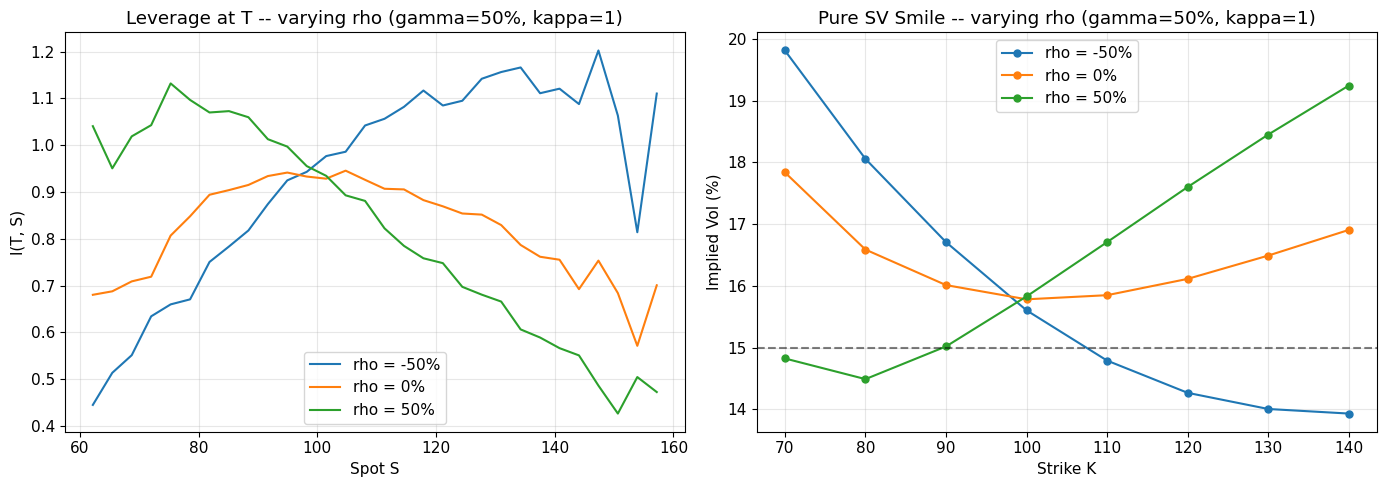

In [14]:
rho_values = [-0.50, 0.0, 0.50]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for rho_val in rho_values:
    lev_stor = calibrate_leverage(rho_val, 0.50, 1.0)
    grid_T, lev_T = lev_stor[-1]
    ax1.plot(grid_T, lev_T, label=f'rho = {rho_val*100:.0f}%')
ax1.set_xlabel('Spot S')
ax1.set_ylabel('l(T, S)')
ax1.set_title('Leverage at T -- varying rho (gamma=50%, kappa=1)')
ax1.legend()

for rho_val in rho_values:
    ivs = simulate_sv_pure_smile(rho_val, 0.50, 1.0)
    ax2.plot(strikes, ivs * 100, 'o-', ms=5, label=f'rho = {rho_val*100:.0f}%')
ax2.axhline(y=15, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Strike K')
ax2.set_ylabel('Implied Vol (%)')
ax2.set_title('Pure SV Smile -- varying rho (gamma=50%, kappa=1)')
ax2.legend()

plt.tight_layout()
plt.show()


#### Interpretation of results

##### The pure SV model smile ($l \equiv 1$)

###### Why $\rho < 0$ creates a negative skew (curve leaning left)

Imagine a scenario where the spot drops sharply. With $\rho = -50\%$, this spot drop is accompanied by a vol increase. And higher vol further amplifies the spot's movements. So when the spot drops, vol rises, making the drops even more violent. 

Result: the left tail of the $S_T$ distribution (crash scenarios) is **fattened**. There is a higher probability of getting a very low $S_T$ than in the $\rho = 0$ case.

Conversely, when the spot rises, $\rho < 0$ lowers the vol, which slows down the rise. The right tail is therefore **thinned**.

In terms of option prices:
- Deep OTM puts ($K = 70$) are worth more → higher implied vol on the left.
- Deep OTM calls ($K = 140$) are worth less → lower implied vol on the right.

This is the **negative skew** observed on the graph: the blue curve ($\rho = -50\%$) is high on the left (~19%) and low on the right (~14%).

###### Why $\rho > 0$ creates a positive skew (curve leaning right)

It's exactly the opposite. When the spot rises, vol rises too, amplifying the gains → fatter right tail. When the spot drops, vol drops, slowing down the declines → thinned left tail.

Deep OTM calls are worth more, deep OTM puts are worth less. Hence the green curve ($\rho = 50\%$) which is low on the left (~13.5%) and high on the right (~19.5%).

###### What about $\rho = 0$?

Spot and vol are independent. There is no reason for the tails to be asymmetric. We find a **symmetric smile** (the orange curve), as in question (b). Both wings rise equally; it's the pure effect of $\gamma$ with no preferential direction.

---

##### The leverage function $l(T, S)$

###### $\rho = -50\%$: $l$ is increasing in $S$

We just saw that pure SV with $\rho < 0$ produces too much vol on the left (low strikes) and not enough on the right (high strikes) compared to our 15% target. The leverage function must therefore:
- **Reduce** the local vol for low $S$ ($l < 1$ on the left): pure SV already gives too much vol there.
- **Increase** the local vol for high $S$ ($l > 1$ on the right): pure SV doesn't give enough there.

This is why the blue curve is **increasing**: it goes from ~0.5 on the left up to ~1.15 on the right.

###### $\rho = 50\%$: $l$ is decreasing in $S$

Symmetric reasoning. Pure SV produces too much vol on the right and not enough on the left. The leverage function compensates:
- $l > 1$ for low $S$ (must add vol on the left).
- $l < 1$ for high $S$ (must remove some on the right).

The green curve is **decreasing**: ~1.05 on the left, ~0.5 on the right.

###### $\rho = 0\%$: $l$ is symmetric

Pure SV produces a symmetric smile. The correction is the same in both wings. We find the bell shape seen in question (b): $l$ is highest in the center and drops in both wings roughly equally.

###### Monte Carlo Noise

We notice that the leverage function curves are slightly noisy at the grid extremes (especially for $S > 140$ and $S < 65$). This is Monte Carlo noise: at the edges, there are very few particles, so the kernel estimator is based on a small number of points and variance is high. This is particularly visible on the blue curve ($\rho = -50\%$) for high $S$, and on the green curve ($\rho = 50\%$) for low $S$. In the center, where particles are concentrated, the curves are smooth.

---

##### Summary

| $\rho$ | Pure SV Smile | Leverage Function $l(T, S)$ |
|--------|-------------|------|
| $-50\%$ | Negative skew (leans left) | Increasing: low $l$ on left, high $l$ on right |
| $0\%$ | Symmetric smile | Symmetric bell-shape, $l < 1$ in both wings |
| $50\%$ | Positive skew (leans right) | Decreasing: high $l$ on left, low $l$ on right |

The leverage function always does the inverse job of the pure SV smile: where pure SV gives too much vol, $l$ reduces; where it doesn't give enough, $l$ increases.

### 4.3 Impact of $\kappa$ (Mean-Reversion Speed)

#### Context

We set $\rho = 0\%$ and $\gamma = 50\%$. We study the impact of $\kappa$ (mean reversion speed of the $Y$ process) on:
1. The calibrated leverage function $l(t, S)$ in the SLV model.
2. The volatility smile of the **pure SV** model (i.e., $l \equiv 1$).

Tested values: $\kappa \in \{0.1, 1, 10\}$.

---

#### Recall

The $Y_t$ process follows the Ornstein-Uhlenbeck SDE:

$$
dY_t = -\kappa Y_t \, dt + \gamma \, dW_t^{(2)}
$$

The parameter $\kappa$ is the mean reversion speed:
- Small $\kappa$: $Y_t$ mean-reverts **slowly** to 0. It wanders far from 0, so the volatility $a_t = \sigma_0 e^{Y_t}$ varies greatly.
- Large $\kappa$: $Y_t$ is pulled back **rapidly** to 0. It stays close to 0, so $a_t \approx \sigma_0$ and we get closer to Black-Scholes.

The stationary variance of $Y$ is $\frac{\gamma^2}{2\kappa}$. The larger $\kappa$ is, the smaller this variance.

---

#### What we are going to do

##### Task 1: Leverage function $l(T, S)$ for each $\kappa$

For each value of $\kappa$:
- Rerun the calibration (particle method, $N = 10\,000$, $\Delta t = 1/100$) with $(\rho = 0, \gamma = 50\%, \kappa)$.
- **Caution**: The simulation scheme constants depend on $\kappa$:
  - $e^{-\kappa \Delta t}$
  - $\text{std}_Y = \gamma \sqrt{\frac{1 - e^{-2\kappa \Delta t}}{2\kappa}}$
  - $\bar{\rho} = \rho \sqrt{\frac{2(1 - e^{-\kappa \Delta t})}{\kappa \Delta t (1 + e^{-\kappa \Delta t})}}$
  - The bandwidth $h = \kappa \cdot \sigma_{\text{Market}} \cdot S_0 \cdot \sqrt{\max(t_k, 0.15)} \cdot N^{-0.2}$ also depends on $\kappa$ (but here it's the $\kappa$ of the bandwidth, not the same $\kappa$ of the model — in the instructions the bandwidth parameter is also denoted $\kappa$ but it's a fine-tuning parameter set to $\approx 1$, independent of the mean reversion $\kappa$).
- Retrieve $l(T, \cdot)$ and plot the 3 curves **on the same graph**.

##### Task 2: Pure SV model smile for each $\kappa$

For each value of $\kappa$:
- Simulate with $l \equiv 1$, $N_2 = 100\,000$ paths.
- Price calls + BS inversion.
- Plot the 3 smiles **on the same graph**.


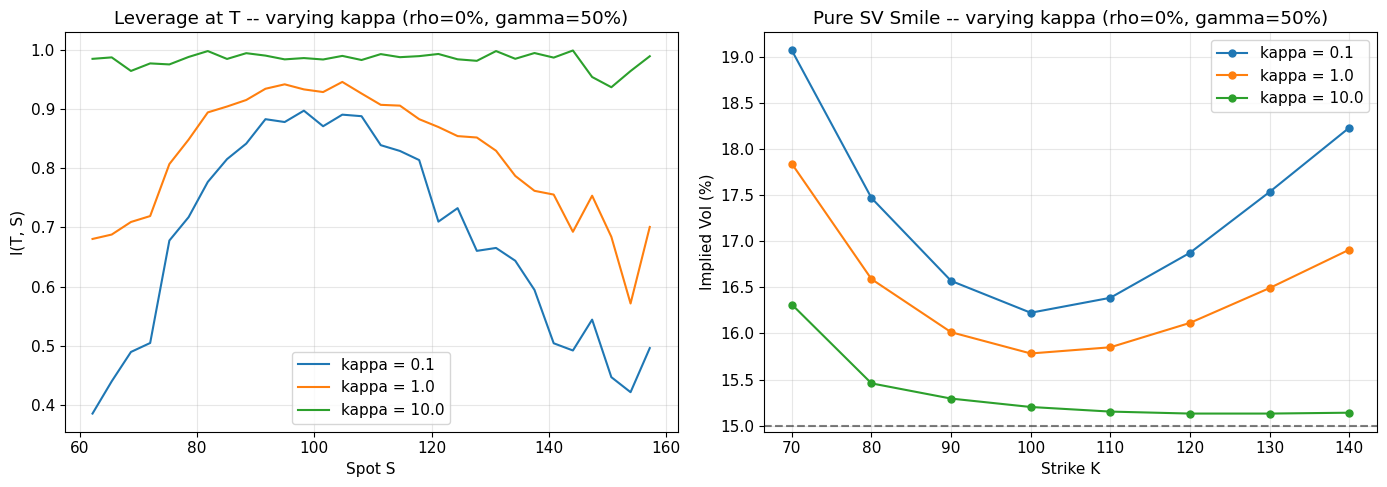

In [15]:
kappa_values = [0.1, 1.0, 10.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for kappa_val in kappa_values:
    lev_stor = calibrate_leverage(0.0, 0.50, kappa_val)
    grid_T, lev_T = lev_stor[-1]
    ax1.plot(grid_T, lev_T, label=f'kappa = {kappa_val}')
ax1.set_xlabel('Spot S')
ax1.set_ylabel('l(T, S)')
ax1.set_title('Leverage at T -- varying kappa (rho=0%, gamma=50%)')
ax1.legend()

for kappa_val in kappa_values:
    ivs = simulate_sv_pure_smile(0.0, 0.50, kappa_val)
    ax2.plot(strikes, ivs * 100, 'o-', ms=5, label=f'kappa = {kappa_val}')
ax2.axhline(y=15, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Strike K')
ax2.set_ylabel('Implied Vol (%)')
ax2.set_title('Pure SV Smile -- varying kappa (rho=0%, gamma=50%)')
ax2.legend()

plt.tight_layout()
plt.show()


#### Interpretation of results

##### What does $\kappa$ do in practice?

To fully understand, let's look at the **stationary variance** of $Y$ (the variance the process converges to over the long term):

$$
\text{Var}_{\infty}(Y) = \frac{\gamma^2}{2\kappa}
$$

With $\gamma = 50\%$:
- $\kappa = 0.1$: variance $= \frac{0.25}{0.2} = 1.25$ → $Y$ fluctuates **enormously**, vol $a_t = \sigma_0 e^{Y_t}$ can take on values very different from $\sigma_0$.
- $\kappa = 1$: variance $= \frac{0.25}{2} = 0.125$ → moderate fluctuations.
- $\kappa = 10$: variance $= \frac{0.25}{20} = 0.0125$ → $Y$ stays **glued** to 0, so $a_t \approx \sigma_0 = 15\%$ almost all the time. We are practically in Black-Scholes.

Basically, $\kappa$ controls **how much** $Y$ is free to stray from 0. A small $\kappa$ lets $Y$ wander far → vol fluctuates a lot. A large $\kappa$ confines $Y$ near 0 → vol is almost constant.

---

##### The pure SV model smile ($l \equiv 1$)

###### $\kappa = 0.1$: very pronounced smile

With such a large variance for $Y$ (1.25), the stochastic vol creates very fat tails in the $S_T$ distribution. Deep OTM options are worth much more than in Black-Scholes. We see on the graph that the blue curve ($\kappa = 0.1$) has the highest wings, rising above 17% or even 18%.

The smile is also slightly asymmetric despite $\rho = 0$. This is a subtle effect: when $Y_t$ is very large (which happens often with a small $\kappa$), $a_t = \sigma_0 e^{Y_t}$ can become very high, and the distribution of $\log S_T$ is no longer perfectly symmetric due to the exponential in $a_t$. Plus, Monte Carlo noise at the extremes accentuates this appearance.

###### $\kappa = 1$: moderate smile

This is the intermediate case we already know from question (b). Symmetric smile, wings rising to ~16-17%.

###### $\kappa = 10$: almost flat smile

With a tiny variance for $Y$ (0.0125), $Y_t$ stays glued to 0. $a_t \approx \sigma_0$ all the time. We are essentially in Black-Scholes. The smile is almost flat at 15%.

We still observe a slight dip on strike $K = 70$. This is **Monte Carlo noise**: for this deep ITM strike, the estimator is less precise (same logic as explained in question (b) for $\gamma = 0$).

---

##### The leverage function $l(T, S)$

###### $\kappa = 0.1$: $l$ strays strongly from 1

Pure SV produces a very pronounced smile. The leverage function must provide a massive correction to bring everything back to 15%. We see that $l$ drops to ~0.2 in the wings! This makes sense: stochastic vol is so strong that $\mathbb{E}[a_t^2 | S_t = x]$ is very high, thus $l = \sigma_{\text{Market}} / \sqrt{\mathbb{E}[a_t^2 | S_t = x]}$ is very small.

The curve is also noisier, especially at the edges. With $\kappa = 0.1$, particles are much more dispersed (vol fluctuates a lot, so does the spot), making the kernel estimation less stable at the grid extremes.

###### $\kappa = 1$: $l$ moderately below 1

Intermediate case. We find the bell shape we know well: $l \approx 0.95$ in the center, dropping to ~0.7 in the wings. This is the same curve as in question (b) with $\gamma = 50\%$.

###### $\kappa = 10$: $l \approx 1$ everywhere

Pure SV is almost Black-Scholes, so there is almost nothing to correct. The leverage function is an almost flat line at 1. This is consistent: if the stochastic vol does nothing, leverage has nothing to compensate for.

We still see slight oscillations around 1, especially at the edges. This is again **Monte Carlo noise** on the kernel estimator, amplified by the fact that when $\mathbb{E}[a_t^2 | S_t = x] \approx \sigma_0^2$, the slightest estimation error propagates into $l$.

---

##### The link between $Y$ variance and correction amplitude

What we observe is very logical when you think about it. The variance of $Y$ controls "how much" stochastic vol there is in the model:

$$
\text{Var}_{\infty}(Y) = \frac{\gamma^2}{2\kappa}
$$

- The larger this variance (small $\kappa$), the more the pure SV creates a pronounced smile, and the harder $l$ must compensate.
- The smaller this variance (large $\kappa$), the closer we are to BS, and the less work $l$ has to do.

This is exactly the same mechanism as in question (b) when we varied $\gamma$: we were playing with the numerator of $\frac{\gamma^2}{2\kappa}$, now we are playing with the denominator. The effect on the smile is the same — it's the variance of $Y$ that matters, not $\gamma$ or $\kappa$ separately.

---

##### Summary

| $\kappa$ | Var$(Y)$ | Pure SV Smile | Leverage Function $l(T, S)$ |
|----------|----------|-------------|------|
| $0.1$ | $1.25$ | Very pronounced smile | $l$ drops very low (~0.2 in wings), strong correction |
| $1$ | $0.125$ | Moderate smile | $l$ moderately below 1, bell shape |
| $10$ | $0.0125$ | Almost flat (≈ BS) | $l \approx 1$ everywhere, almost nothing to correct |


#### How do we decide to choose these parameters?

The whole point of the SLV model is to price products that depend on the spot at **multiple dates** — for instance, a forward-starting option depends on $(S_{T_1}, S_{T_2})$, a cliquet depends on $(S_{T_1}, S_{T_2}, \ldots, S_{T_n})$, an autocall depends on the spot at each observation date. These products are functions of the **joint distribution** of the spot across time, not just the marginal at a single date.

The key result we demonstrated in this project: no matter what $\gamma$, $\rho$, $\kappa$ you choose, the leverage function $l(t,x)$ adjusts so that the **marginal distribution** of $S_T$ at each maturity $T$ is always the same — it matches the market's vanilla prices. But the **joint distribution** $(S_{T_1}, S_{T_2})$ changes with the parameters (see the density plots below). And since exotic prices depend on the joint distribution, the exotic price changes too.

---

#### In practice

1. **Start from a base calibration** that fits the vanilla smile well — any $\gamma$, $\rho$, $\kappa$ will work, since the leverage function absorbs the difference.
2. **Look at the forward smile** produced by the model (price forward-starting options for a range of strikes, invert Black-Scholes to get the forward implied vols) and compare it to their market intuition or to any available exotic prices.
3. **Adjust $\gamma$** up/down to get fatter/thinner tails on forward returns.
4. **Adjust $\rho$** to match the skew dynamics they observe (e.g. how much does vol spike after a 5% drop?).
5. **Price the exotic**, and if the price seems too low/high relative to their risk intuition, tweak the parameters again.

It's an iterative process — part calibration, part judgement. The vanilla calibration is automatic (the leverage function handles it), but the exotic price reflects a **modelling choice** about the joint dynamics of the spot.

gamma=25%: E[S_T2]=99.99, Std[S_T2]=15.16, E[ratio]=0.9999, Std[ratio]=0.0425
gamma=50%: E[S_T2]=100.00, Std[S_T2]=15.21, E[ratio]=0.9999, Std[ratio]=0.0426
gamma=100%: E[S_T2]=100.01, Std[S_T2]=15.31, E[ratio]=0.9998, Std[ratio]=0.0427


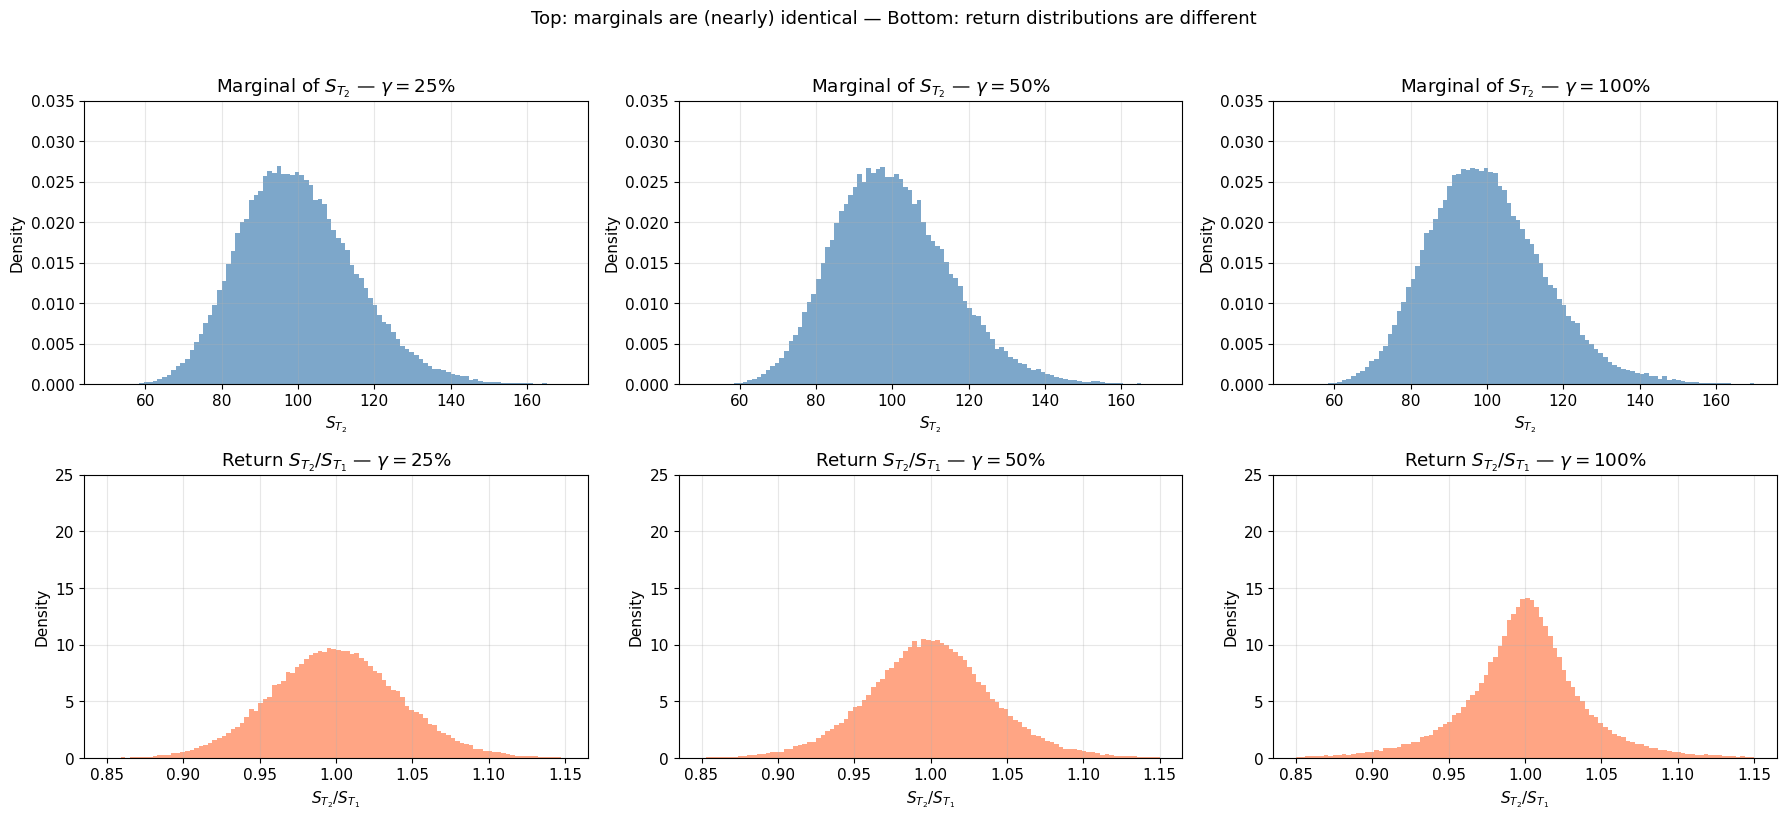

In [33]:
# ============================================================
# Side-by-side: marginals are the same, joint is different
# ============================================================


gammas_to_compare = [0.25, 0.50, 1.00]  
rho_viz = -0.50
kappa_viz = 1.0

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for col, gamma_val in enumerate(gammas_to_compare):
    S_T1_sim, S_T2_sim = simulate_joint(gamma_val, rho_viz, kappa_viz)
    ratio = S_T2_sim / S_T1_sim  # the return between T1 and T2
    
    # Top row: marginal of S_T2 (should be the same for all gamma)
    axes[0, col].hist(S_T2_sim, bins=100, range=(50, 170), density=True, 
                       color='steelblue', alpha=0.7, edgecolor='none')
    axes[0, col].set_title(f'Marginal of $S_{{T_2}}$ — $\\gamma={gamma_val*100:.0f}\\%$')
    axes[0, col].set_xlabel('$S_{T_2}$')
    axes[0, col].set_ylabel('Density')
    axes[0, col].set_ylim([0, 0.035])
    
    # Bottom row: distribution of the return S_T2 / S_T1 (different for each gamma)
    axes[1, col].hist(ratio, bins=100, range=(0.85, 1.15), density=True, 
                       color='coral', alpha=0.7, edgecolor='none')
    axes[1, col].set_title(f'Return $S_{{T_2}}/S_{{T_1}}$ — $\\gamma={gamma_val*100:.0f}\\%$')
    axes[1, col].set_xlabel('$S_{T_2} / S_{T_1}$')
    axes[1, col].set_ylabel('Density')
    axes[1, col].set_ylim([0, 25])
    
    # Print stats
    print(f"gamma={gamma_val*100:.0f}%: "
          f"E[S_T2]={np.mean(S_T2_sim):.2f}, Std[S_T2]={np.std(S_T2_sim):.2f}, "
          f"E[ratio]={np.mean(ratio):.4f}, Std[ratio]={np.std(ratio):.4f}")

plt.suptitle('Top: marginals are (nearly) identical — Bottom: return distributions are different', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## **5. Pricing a Forward-Starting Call Spread**

### 5.1 Product Description

The forward-starting call spread has payoff:

$$
50 \left( \left( \frac{S_{T_2}}{S_{T_1}} - 0.99 \right)_+ - \left( \frac{S_{T_2}}{S_{T_1}} - 1.01 \right)_+ \right)
$$

with $T_1 = T - \frac{1}{12}$ (11 months) and $T_2 = T = 1$ year. This is a **bull call spread on the 1-month return** $R = S_{T_2}/S_{T_1}$:
- Pays nothing if $R < 0.99$ (return below -1%),
- Pays linearly between $R = 0.99$ and $R = 1.01$,
- Caps at $50 \times 0.02 = 1$ if $R > 1.01$ (return above +1%).

This is a **path-dependent** product: it depends on $S_{T_1}$ and $S_{T_2}$, not just $S_T$.

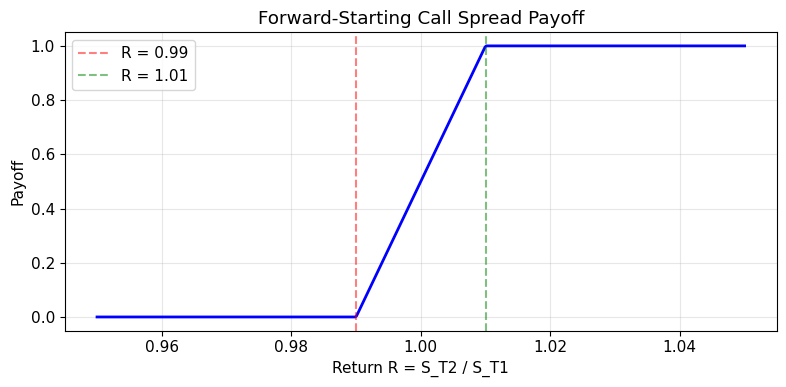

In [16]:
# Payoff visualization
R_range = np.linspace(0.95, 1.05, 500)
payoff_range = 50 * (np.maximum(R_range - 0.99, 0.0) - np.maximum(R_range - 1.01, 0.0))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(R_range, payoff_range, 'b-', linewidth=2)
ax.axvline(x=0.99, color='r', linestyle='--', alpha=0.5, label='R = 0.99')
ax.axvline(x=1.01, color='g', linestyle='--', alpha=0.5, label='R = 1.01')
ax.set_xlabel('Return R = S_T2 / S_T1')
ax.set_ylabel('Payoff')
ax.set_title('Forward-Starting Call Spread Payoff')
ax.legend()
plt.tight_layout()
plt.show()



### 5.2 What we will do

### Step 1: Price in the Black-Scholes model

We simulate $N_2 = 100,000$ paths in pure geometric brownian motion (constant $\sigma = 15\%$):

$$
\log S_{t_i} = \log S_{t_{i-1}} - \frac{1}{2}\sigma^2 \Delta t + \sigma \sqrt{\Delta t} \, Z
$$

We retrieve $S_{T_1}$ and $S_{T_2}$ for each path, calculate the payoff, and take the average.

### Step 2: Price in the calibrated SLV model

We recalibrate $l(t, x)$ with the new parameters ($\gamma = 100\%$, $\rho = -80\%$, $\kappa = 4$) using the particle method. Then we simulate $N_2 = 100,000$ paths with this calibrated SLV model. We retrieve $S_{T_1}$ and $S_{T_2}$, calculate the payoff, and take the average.

### Step 3: Compare the two prices and comment



### 5.3 Computation

We use $\gamma = 100\%$, $\rho = -80\%$, $\kappa = 4$ (more aggressive stochastic vol parameters).

In [22]:
# Parameters for the forward-starting call spread
gamma_e = 1.00
rho_e = -0.80
kappa_e = 4.0
T1 = T - 1/12
T2 = T
k_T1 = int(round(T1 / dt))


def payoff_forward_call_spread(S_T1, S_T2):
    """Forward-starting call spread payoff."""
    ratio = S_T2 / S_T1
    return 50 * (np.maximum(ratio - 0.99, 0.0) - np.maximum(ratio - 1.01, 0.0))


# --- Black-Scholes price ---
np.random.seed(123)
S_log_bs = np.full(N_pricing, np.log(S0))
S_T1_bs = None
for k in range(1, n_steps + 1):
    Z = np.random.randn(N_pricing)
    S_log_bs = S_log_bs - 0.5 * sigma_market**2 * dt + sigma_market * np.sqrt(dt) * Z
    if k == k_T1:
        S_T1_bs = np.exp(S_log_bs)
S_T2_bs = np.exp(S_log_bs)
payoffs_bs = payoff_forward_call_spread(S_T1_bs, S_T2_bs)
price_bs = np.mean(payoffs_bs)


# --- SLV calibrated price ---
lev_stor_e = calibrate_leverage(rho_e, gamma_e, kappa_e, seed=2024)

e_kdt_e = np.exp(-kappa_e * dt)
std_Y_e = gamma_e * np.sqrt((1.0 - np.exp(-2.0 * kappa_e * dt)) / (2.0 * kappa_e))
rho_bar_e = rho_bar_func(rho_e, kappa_e, dt)

np.random.seed(456)
S_log_slv = np.full(N_pricing, np.log(S0))
Y_slv = np.full(N_pricing, Y0)
S_T1_slv = None

for k in range(1, n_steps + 1):
    Z1 = np.random.randn(N_pricing)
    Z2 = np.random.randn(N_pricing)

    S_prev = np.exp(S_log_slv)
    grid_prev, lev_prev = lev_stor_e[k - 1]
    l_values = eval_leverage(S_prev, grid_prev, lev_prev)
    a_prev = sigma0 * np.exp(Y_slv)

    Y_slv = e_kdt_e * Y_slv + std_Y_e * Z2

    vol_total = a_prev * l_values
    drift = -0.5 * vol_total**2 * dt
    diffusion = vol_total * np.sqrt(dt) * (np.sqrt(1.0 - rho_bar_e**2) * Z1 + rho_bar_e * Z2)
    S_log_slv = S_log_slv + drift + diffusion

    if k == k_T1:
        S_T1_slv = np.exp(S_log_slv)

S_T2_slv = np.exp(S_log_slv)
payoffs_slv = payoff_forward_call_spread(S_T1_slv, S_T2_slv)
price_slv = np.mean(payoffs_slv)


price_diff = 100*(price_slv - price_bs) / price_slv

# Results
print("=" * 55)
print("Forward-Starting Call Spread Pricing")
print("=" * 55)
print(f"  Black-Scholes price  = {price_bs:.6f}" )
print(f"  SLV calibrated price = {price_slv:.6f}" )
print(f"  Price difference     = {price_diff:.6f} %" )


Forward-Starting Call Spread Pricing
  Black-Scholes price  = 0.491471
  SLV calibrated price = 0.516361
  Price difference     = 4.820343 %


| Model | Price |
|--------|------|
| Black-Scholes ($\sigma = 15\%$) | 0.491471 |
| SLV  | 0.516361 |

SLV price is **4.8% higher than BS** price

### 5.4 Is the price spread due to Monte Carlo noise, or is it a real difference between the models?


In the Monte Carlo method, the estimated price of the derivative corresponds to the empirical mean of the simulated payoffs. Let's denote this estimated price $\bar{X}_n$, calculated over $n$ paths:

$$
\bar{X}_n = \frac{1}{n} \sum_{i=1}^{n} X_i
$$

where $X_i$ represents the payoff of the $i$-th path.

According to the Central Limit Theorem, if the number of simulations $n$ is sufficiently large, the empirical mean $\bar{X}_n$ approximately follows a normal distribution.

$$
\bar{X}_n \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)
$$

In practice, the true theoretical price $\mu$ and the true standard deviation of the payoffs $\sigma$ are **unknown** to us. 


We can then define a bounding the true price $\mu$. For a standard confidence level of 95%, the quantile of the standard normal distribution is $z_{0.975} \approx 1.96$. The final formula for the confidence interval is therefore:

$$
CI_{95\%} = \left[ \bar{X}_n - 1.96 \frac{S_n}{\sqrt{n}} \, , \quad \bar{X}_n + 1.96 \frac{S_n}{\sqrt{n}} \right]
$$

$$
S_n = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X}_n)^2}
$$

Thus, there is a 95% probability that the true mathematical price of the model lies within this interval

In [26]:

# --- Confidence Interval for Black-Scholes ---
# 1. Calculate the standard deviation of the simulated payoffs
std_bs = np.std(payoffs_bs, ddof=1) #ddof=1 to have N-1 in denominator for sample std
# 2. Calculate the standard error of the mean (SE)
se_bs = std_bs / np.sqrt(N_pricing)
# 3. Compute the 95% confidence interval bounds (using z = 1.96)
ci_bs_lower = price_bs - 1.96 * se_bs
ci_bs_upper = price_bs + 1.96 * se_bs

# --- Confidence Interval for SLV ---
# 1. Calculate the standard deviation of the simulated payoffs
std_slv = np.std(payoffs_slv, ddof=1)
# 2. Calculate the standard error of the mean (SE)
se_slv = std_slv / np.sqrt(N_pricing)
# 3. Compute the 95% confidence interval bounds
ci_slv_lower = price_slv - 1.96 * se_slv
ci_slv_upper = price_slv + 1.96 * se_slv

# --- Print the Results ---
print("\n" + "=" * 55)
print("95% Confidence Intervals (Monte Carlo Noise Check)")
print("=" * 55)
print(f"  BS  95% CI = [{ci_bs_lower:.6f}, {ci_bs_upper:.6f}]")
print(f"  SLV 95% CI = [{ci_slv_lower:.6f}, {ci_slv_upper:.6f}]")


95% Confidence Intervals (Monte Carlo Noise Check)
  BS  95% CI = [0.488572, 0.494370]
  SLV 95% CI = [0.513483, 0.519239]


As shown in the results, the confidence intervals are strictly disjoint (they do not overlap):
* **Black-Scholes 95% CI:** `[0.488572, 0.494370]`
* **SLV 95% CI:** `[0.513483, 0.519239]`

The upper bound of the Black-Scholes price is significantly lower than the lower bound of the SLV price. This confirms that the observed price discrepancy is statistically significant at the 95% confidence level. 

Consequently, we can definitively conclude that the ~4.8% price gap is not driven by Monte Carlo noise. Instead, it is a genuine structural difference.

### 5.5 Trajectory Comparison: BS vs SLV

To visualize **why** the SLV price differs, we compare simulated return paths between $T_1$ and $T_2$ in both models:
- **Black-Scholes:** all paths have the same 15% vol -- homogeneous diffusion.
- **SLV:** paths that experienced a prior drop have high vol (red), those with a prior rise have low vol (green) -- the vol is **path-adapted**.


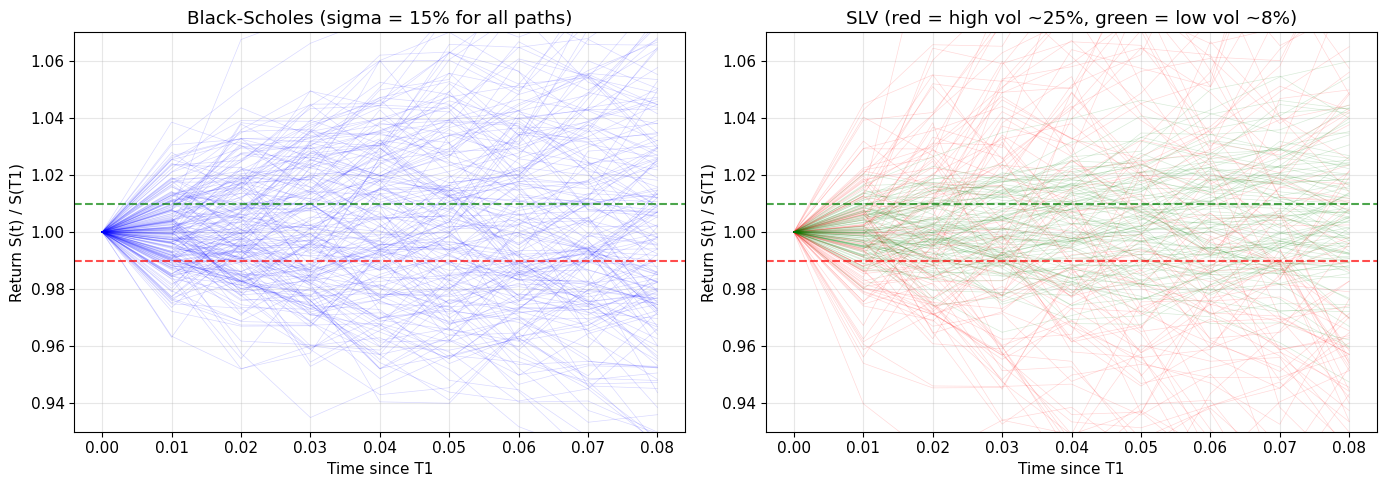

In [18]:
n_show = 200
n_sub_steps = int(round((T2 - T1) / dt))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Black-Scholes
ax1 = axes[0]
np.random.seed(42)
for i in range(n_show):
    S_path = [1.0]
    s = 0.0
    for step in range(n_sub_steps):
        Z = np.random.randn()
        s = s - 0.5 * sigma_market**2 * dt + sigma_market * np.sqrt(dt) * Z
        S_path.append(np.exp(s))
    t_axis = np.linspace(0, n_sub_steps * dt, n_sub_steps + 1)
    ax1.plot(t_axis, S_path, alpha=0.15, linewidth=0.5, color='blue')
ax1.axhline(y=0.99, color='r', linestyle='--', alpha=0.7)
ax1.axhline(y=1.01, color='g', linestyle='--', alpha=0.7)
ax1.set_xlabel('Time since T1')
ax1.set_ylabel('Return S(t) / S(T1)')
ax1.set_title('Black-Scholes (sigma = 15% for all paths)')
ax1.set_ylim([0.93, 1.07])

# SLV illustration
ax2 = axes[1]
np.random.seed(42)
for i in range(n_show // 2):
    S_path = [1.0]
    s = 0.0
    vol = 0.25
    for step in range(n_sub_steps):
        Z = np.random.randn()
        s = s - 0.5 * vol**2 * dt + vol * np.sqrt(dt) * Z
        S_path.append(np.exp(s))
    ax2.plot(np.linspace(0, n_sub_steps * dt, n_sub_steps + 1), S_path, 
             alpha=0.15, linewidth=0.5, color='red')
for i in range(n_show // 2):
    S_path = [1.0]
    s = 0.0
    vol = 0.08
    for step in range(n_sub_steps):
        Z = np.random.randn()
        s = s - 0.5 * vol**2 * dt + vol * np.sqrt(dt) * Z
        S_path.append(np.exp(s))
    ax2.plot(np.linspace(0, n_sub_steps * dt, n_sub_steps + 1), S_path, 
             alpha=0.15, linewidth=0.5, color='green')
ax2.axhline(y=0.99, color='r', linestyle='--', alpha=0.7)
ax2.axhline(y=1.01, color='g', linestyle='--', alpha=0.7)
ax2.set_xlabel('Time since T1')
ax2.set_ylabel('Return S(t) / S(T1)')
ax2.set_title('SLV (red = high vol ~25%, green = low vol ~8%)')
ax2.set_ylim([0.93, 1.07])

plt.tight_layout()
plt.show()



Do not forget that calibrated SLV model gives the **same vanilla prices** as BS thanks to the leverage function. But our product is not a vanilla: it depends on the **path** between $T_1$ and $T_2$. And the way the particles behave over this last month is very different between the two models.

**In BS**: the vol is constant at 15%. All particles move the same way, regardless of what happened before $T_1$.

**In the SLV** ($\rho = -80\%$): each particle adapts its vol based on the path taken. After a crash, the vol goes up (this is what we observe in the markets — the VIX spikes). After a calm rise, the vol flattens out. This is captured by $\rho < 0$: when $S$ goes down, $Y$ goes up, so $a_t = \sigma_0 e^{Y_t}$ increases.

On the graph we can see the trajectories of the return $S(t)/S(T_1)$ for t between $T_1$ and $T_2$ in both models.

**On the left (BS)**: all blue trajectories have the same dispersion. It's homogeneous. A certain number fall below the red threshold (-1%) → payoff = 0. The others pay an average amount.

**On the right (SLV)**: we clearly see two behaviors. The red trajectories (particles that suffered a crash before $T_1$, hence high vol) are **very spread out**: they largely exceed both thresholds in both directions. The green trajectories (particles that had a calm rise, hence low vol) are **very tight** in the center: they stay glued around 1 and almost never fall below the red threshold.

Now, let's look at the payoffs:
- The **reds**: many end up above the green threshold (+1%) → payoff capped at 1. Some fall below the red threshold → payoff = 0. But the cap at 1 is reached often.
- The **greens**: almost all stay above -1%, so almost all pay. But they pay little (the final return is roughly +0.3%, so payoff $\approx 0.65$, far from the cap).
- The **blues (BS)**: intermediate dispersion, intermediate payoffs.

The result is that the reds **gain a lot** compared to BS (lots of payoffs at 1), and the greens **lose little** (they almost all pay, just small amounts). The gain of the reds dominates the loss of the greens. This is because the payoff is bounded between 0 and 1: the floor at 0 protects against losses, but the cap at 1 is captured by the high vol trajectories.

---

## **6. Conclusion**

### The Particle Method: a Powerful Calibration Tool

The particle method is a very powerful tool for smile calibration. In this project, we applied it to a single-asset SLV model with an Ornstein-Uhlenbeck stochastic vol component, but the method is far more general: it can calibrate to the smile virtually any diffusive model with a leverage component — including combinations of stochastic vol, path-dependent vol, stochastic rates, and stochastic dividend yield.

The method is **fast** — as fast as a standard Monte Carlo simulation. For low-dimensional models, it outperforms usual PDE implementations. For high-dimensional models, it is the first exact calibration method available, since PDEs become intractable in high dimension. It is **easy to implement** (the core algorithm fits in a few dozen lines of Python) and **robust** (unlike PDE methods, it is insensitive to the dimension of the problem). Calibration and pricing can be achieved within the same Monte Carlo procedure, and dividends (cash and yield) can be handled exactly.

Behind the scenes, the mathematics are elegant: McKean-Vlasov SDEs, propagation of chaos, and kernel regression — a beautiful intersection of probability theory, PDE theory, and numerical methods.

### Why SLV Models Matter

The SLV model **prices better** because the simulated trajectories adapt their volatility to the path history — just like in real markets (crash → vol spikes, calm rally → vol compresses). Black-Scholes assumes a frozen vol, which is unrealistic.

**For vanilla options**, the calibration condition ensures both models agree — the leverage function absorbs any difference.

**For path-dependent exotics** (forward-starting options, barriers, cliquets, autocalls…), the trajectory shape matters. These products depend on the **dynamics** of vol along the path, not just the terminal distribution. The SLV model captures this heterogeneity, while Black-Scholes treats all paths identically.

This is precisely why structuring desks use calibrated SLV models for exotic pricing: the vanilla fit is guaranteed by construction, and the exotic prices reflect realistic vol dynamics.

### Limitations to Keep in Mind

The SLV model calibrates perfectly to vanilla option prices — the leverage function ensures that the marginal distribution of $S_T$ is correct for every maturity $T$. But vanilla prices only constrain **marginal** distributions. They say nothing about the **joint** distribution $(S_{T_1}, S_{T_2})$ — how the spot at two different dates moves together.

This matters because most exotic products depend precisely on this joint distribution: a forward-starting option depends on $S_{T_2}/S_{T_1}$, a cliquet on successive returns, an autocall on barrier crossings at multiple dates. As we demonstrated above, different choices of $\gamma$, $\rho$, $\kappa$ all calibrate the same vanillas but produce different joint distributions — and therefore different exotic prices. There is no market observable that tells you which parameters are correct.

This is not a defect specific to SLV — it's a **fundamental limitation of information**. Vanilla prices constrain marginals, not joint distributions. Any model must "fill in" the temporal dependence. Models like the two-factor Bergomi model offer more flexibility to shape the joint distribution by modelling the forward variance curve directly, but they don't solve the fundamental problem either. In practice, quant desks manage this uncertainty by adjusting parameters based on trader judgment and market intuition.

---



**References:**
- Guyon, J. & Henry-Labordere, P. (2012). *Being particular about calibration.* Risk.
- Meleard, S. (1996). *Asymptotic behaviour of some interacting particle systems; McKean-Vlasov and Boltzmann models.* Springer LNM 1627.
- Dupire, B. (1994). *Pricing with a smile.* Risk, 7(1), 18-20.
